In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from algbench import read_as_pandas
from tspn_bnb2.misc.paper_style import FULLWIDEFIGURE, init_params
from tspn_bnb2.schemas import AnnotatedInstance, AnnotatedSolution

init_params()

In [2]:
def read_row(row):
    instance = AnnotatedInstance.model_validate_json(
        row["parameters"]["args"]["kwargs"]["instance_json"]
    )
    solution = AnnotatedSolution.model_validate_json(row["result"]["solution"])

    return {
        "solution": solution,
        "upper_bound": solution.upper_bound,
        "lower_bound": solution.lower_bound,
        "gap": solution.alg_relative_gap,
        "is_optimal": solution.is_optimal,
        "instance_name": row["parameters"]["args"]["kwargs"]["instance_name"],
        "instance": instance,
        "solve_time": row["result"]["solve_time"],
        "n": instance.num_polygons(),
        "decomposition": row["parameters"]["args"]["alg_params"]["decomposition"],
        "instance_type": instance.derive_instance_type(),
    }


benchmark = read_as_pandas("results_decomposition_strategy", read_row)
print("Loaded", len(benchmark), "runs")
benchmark = benchmark.sort_values(by=["instance_type", "decomposition"])

Loaded 136 runs


In [3]:
# validate that solutions are correct.
n_checks = 0
for _, row in benchmark.iterrows():
    solution = row["solution"]
    if solution is None:
        continue
    same_instance = benchmark[benchmark["instance_name"] == row["instance_name"]]

    for _, other in same_instance.iterrows():
        if other["solution"] is None:
            continue
        check = solution.plausibility_check(
            other["solution"],
            eps=0.01,
        )
        if not check["valid"]:
            print(
                f"Check failed for {row['instance_name']}"
                f" {check} {row['solution']}\n"
                f"{row['decomposition']}\n"
                f"{other['solution']}\n"
                f"{other['decomposition']}"
            )
        else:
            n_checks += 1

print(n_checks, "checks succeeded")

272 checks succeeded


In [4]:
benchmark.groupby(["decomposition", "instance_type"])["is_optimal"].value_counts()

decomposition  instance_type  is_optimal
False          OSM            True          27
                              False         13
               random         True          20
               tessellation   True           8
True           OSM            True          27
                              False         13
               random         True          20
               tessellation   True           8
Name: count, dtype: int64

55


/var/folders/tp/x38cpg5x7zd2p54xjvncbjtm0000gn/T/ipykernel_1568/4037177745.py:55: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(


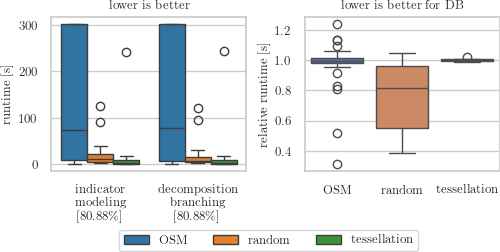

In [6]:
fig, axs = plt.subplots(ncols=2, figsize=FULLWIDEFIGURE)

ax = axs[0]
sns.boxplot(
    benchmark, x="decomposition", y="solve_time", hue="instance_type", palette="tab10", ax=ax
)

xticks = list(ax.get_xticks())
xticklabels = []

for label in ax.get_xticklabels():
    decomp = label.get_text() != "False"

    solutions_for_label = benchmark[(benchmark["decomposition"] == decomp)]
    optimal_percentage = len(solutions_for_label[solutions_for_label["is_optimal"]]) / len(
        solutions_for_label
    )
    label = "decomposition\nbranching" if decomp else "indicator\nmodeling"
    label += f"\n[{round(optimal_percentage * 100, 2)}\\%]"
    xticklabels.append(label)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_title("lower is better")
ax.set_xlabel("decomposition")
ax.set_ylabel("runtime [s]")


# find instances were both were optimal
instances_with_both_opt = [
    inst
    for inst in benchmark["instance_name"].unique()
    if len(benchmark[(benchmark["instance_name"] == inst) & benchmark["is_optimal"]]) == 2
]


bench = benchmark[benchmark["instance_name"].isin(instances_with_both_opt)]

df = {"instance": [], "instance_type": [], "relative_runtime": []}

for _, row in bench[bench["decomposition"]].iterrows():
    other = bench[(~bench["decomposition"]) & (bench["instance_name"] == row["instance_name"])]
    assert len(other) == 1, len(other)
    other = other.iloc[0]

    assert row["is_optimal"] and other["is_optimal"]

    df["instance"].append(row["instance_name"])
    df["instance_type"].append(row["instance_type"])
    df["relative_runtime"].append(row["solve_time"] / other["solve_time"])

df = pd.DataFrame(df)
print(len(df))
sns.boxplot(
    df,
    x="instance_type",
    y="relative_runtime",
    hue="instance_type",
    ax=axs[1],
    palette=sns.color_palette(),
)

axs[1].set_ylabel("relative runtime [s]")
axs[1].set_title("lower is better for DB")
axs[1].set_xlabel("")
axs[0].set_xlabel("")

fig.legend(loc="outside lower center", ncol=3, bbox_to_anchor=(0.5, -0.32))
axs[0].legend().remove()
fig.subplots_adjust(wspace=0.3)
fig.savefig("../plots/rq3_decomposition_branching/runtimes_for_opt.pdf", bbox_inches="tight")

/var/folders/tp/x38cpg5x7zd2p54xjvncbjtm0000gn/T/ipykernel_1568/3421719942.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(


68


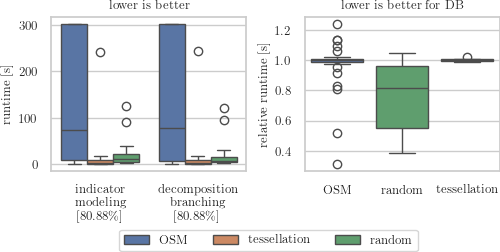

In [8]:
fig, axs = plt.subplots(ncols=2, figsize=FULLWIDEFIGURE)

ax = axs[0]
sns.boxplot(
    benchmark,
    x="decomposition",
    y="solve_time",
    hue="instance_type",
    palette=sns.color_palette(),
    ax=ax,
    hue_order=["OSM", "tessellation", "random"],
)

xticks = list(ax.get_xticks())
xticklabels = []

for label in ax.get_xticklabels():
    decomp = label.get_text() != "False"

    solutions_for_label = benchmark[(benchmark["decomposition"] == decomp)]
    optimal_percentage = len(solutions_for_label[solutions_for_label["is_optimal"]]) / len(
        solutions_for_label
    )
    label = "decomposition\nbranching" if decomp else "indicator\nmodeling"
    label += f"\n[{round(optimal_percentage * 100, 2)}\\%]"
    xticklabels.append(label)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_title("lower is better")
ax.set_xlabel("decomposition")
ax.set_ylabel("runtime [s]")


instances_with_both_opt = [
    inst
    for inst in benchmark["instance_name"].unique()
    if len(benchmark[(benchmark["instance_name"] == inst)]) == 2
]
bench = benchmark[benchmark["instance_name"].isin(instances_with_both_opt)]

df = {"instance": [], "instance_type": [], "relative_runtime": []}

for _, row in bench[bench["decomposition"]].iterrows():
    other = bench[(~bench["decomposition"]) & (bench["instance_name"] == row["instance_name"])]
    assert len(other) == 1, len(other)
    other = other.iloc[0]

    df["instance"].append(row["instance_name"])
    df["instance_type"].append(row["instance_type"])
    df["relative_runtime"].append(row["solve_time"] / other["solve_time"])

df = pd.DataFrame(df)
print(len(df))
sns.boxplot(
    df,
    x="instance_type",
    y="relative_runtime",
    hue="instance_type",
    ax=axs[1],
    hue_order=["OSM", "tessellation", "random"],
)

axs[1].set_ylabel("relative runtime [s]")
axs[1].set_title("lower is better for DB")
axs[1].set_xlabel("")
axs[0].set_xlabel("")

fig.legend(loc="outside lower center", ncol=3, bbox_to_anchor=(0.5, -0.32))
axs[0].legend().remove()
fig.subplots_adjust(wspace=0.3)
fig.savefig("../plots/rq3_decomposition_branching/runtimes_all.pdf", bbox_inches="tight")